# A probabilstic model to assess fairness of a coin

Coin flips and dice throws are the worst kind of statistical examples in my opinion, but here I'd like to use one as a basic example of what a "latent" process may be.

In [1]:
import numpy as np
import scipy.stats as st
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pylab as plt
from matplotlib.gridspec import GridSpec

#az.style.use("arviz-vibrant")

# Setting matplotlib fonts
from matplotlib import rc
font = {'family': 'serif'}
rc('font', **font)


# Below is a set of colors for matplotlib that is colorblind-friendly
# To use them in plotting commands, you can simply set "color=colorset[N]",
# where N is an integer in [0,16), reflecting the index of the colors below.
COLORSET = ['#000000','#00270C','#00443C','#005083',
            '#034BCA','#483CFC','#9C2BFF','#EB24F4',
            '#FF2DC2','#FF4986','#FF7356','#FFA443',
            '#EBD155','#D3F187','#D7FFC8','#FFFFFF']

## Data and premise

Imagine there is a coin that we want to assess what are the chances for getting tails in a coin flip (which we call $C_{\rm{tails}}$). If $C_{\rm{tails}}$ is 0.5, then the coin would be considered fair. However, the issue is that we can never directly measure/observe it, we can only indirectly infer it.

You aquire a sample of coin flips:

$$ x = \{x_0,\cdots,x_i,\cdots,x_N\} $$

where each $x_i$ can be either $=0$ (heads) or $=1$ (tails).

In [2]:
DATA = np.fromfile('coinflips.txt',sep=',')
DATA

array([1., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 1., 0., 0., 0., 0.,
       0., 1., 1., 1., 0., 1., 1., 1., 0., 0., 0., 1., 1., 1., 0., 0., 0.,
       0., 1., 1., 0., 0., 0., 1., 0., 0., 1., 0., 1., 0., 1., 1., 0., 0.,
       1., 1., 0., 1., 0., 0., 1., 1., 1., 0., 1., 1., 1., 0., 0., 0., 0.,
       0., 1., 0., 0., 0., 0., 1., 1., 1., 1., 0., 0., 1., 1., 1., 1., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 1.,
       0., 0., 1., 1., 0., 0., 0., 0., 0., 1., 1.])

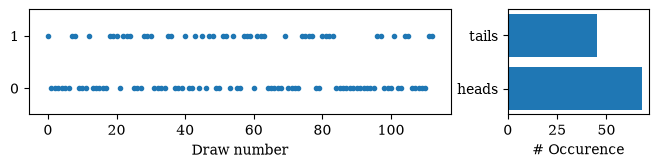

In [3]:
fig_data_barchart = plt.figure(figsize=(8,3))
axgrid = GridSpec(2, 2, width_ratios=[3, 1])
ax1 = fig_data_barchart.add_subplot(axgrid[0])
ax1.plot(DATA,'.')
ax1.set_ylim(-0.5,1.5)
ax1.set_xlabel('Draw number')
ax2 = fig_data_barchart.add_subplot(axgrid[1])
ax2.barh(['heads','tails'],[len(DATA[DATA==0]),len(DATA[DATA==1])])
ax2.set_xlabel('# Occurence');

## Building our model

We make the bold assumption that the observed coin flips are outcomes of a [*Bernoulli process*](https://en.wikipedia.org/wiki/Bernoulli_process), This comes with the following assumptions: 
- There are only 2 possible outcomes in the probability space.
- Coin flips are independent (coin flip $i$ is independent of coin flip $i'$).

Thus, we write the probability mass function of a single coin flip as a Bernoulli function:

$$ P(x_i;C_{\rm{tails}}) =  \begin{cases} 
          1-C_{\rm{tails}} & x_i=0 \\
          C_{\rm{tails}} & x_i=1
       \end{cases}
$$

So, our model becomes:

$$ p(C_{\rm{tails}}|x) \propto p(C_{\rm{tails}}) P(x|C_{\rm{tails}}) $$

We know that $C_{\rm{tails}}$ cannot be outside the range $[0,1]$, and we assume we have no knowledge where the value might be, so:

$$  C_{\rm{tails}} \sim \mathcal{U}(\rm{min}=0,\rm{max}=1)$$

And in our model we assumed our data are the results of a Bernoulli process, thus:

$$ P(x|C_{\rm{tails}}) = \prod_{i=1}^{N} P(x_i|C_{\rm{tails}}) $$


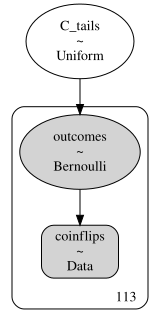

In [4]:
with pm.Model() as coin_model:
    observed_coinflips = pm.Data('coinflips',DATA)
    tails_chance = pm.Uniform('C_tails',0,1)
    outcomes = pm.Bernoulli('outcomes',tails_chance,observed=observed_coinflips)

pm.model_to_graphviz(coin_model)

## Prior, posterior and posterior-predictive sampling

We do all in one go, as prior-predictive checks are not going to be necessary here (it's a very simple, single dimensional model with binary data).

In [5]:
with coin_model:
    prior_samp = pm.sample_prior_predictive(draws=5000)
    post_samp = pm.sample(chains=8, draws=5000)
    pm.sample_posterior_predictive(post_samp,extend_inferencedata=True)

post_samp.update(prior_samp)

Sampling: [C_tails, outcomes]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (8 chains in 4 jobs)
NUTS: [C_tails]


Output()

Sampling 8 chains for 1_000 tune and 5_000 draw iterations (8_000 + 40_000 draws total) took 8 seconds.
Sampling: [outcomes]


Output()

## Convergence and sampling summary

In [6]:
az.style.use("arviz-vibrant")
az.plot_trace_dist(post_samp)
az.summary(post_samp)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
C_tails,0.4004,0.0455,0.33,0.47,16596,23931,1.00,0.00035,0.00025


## Comparing prior to posterior

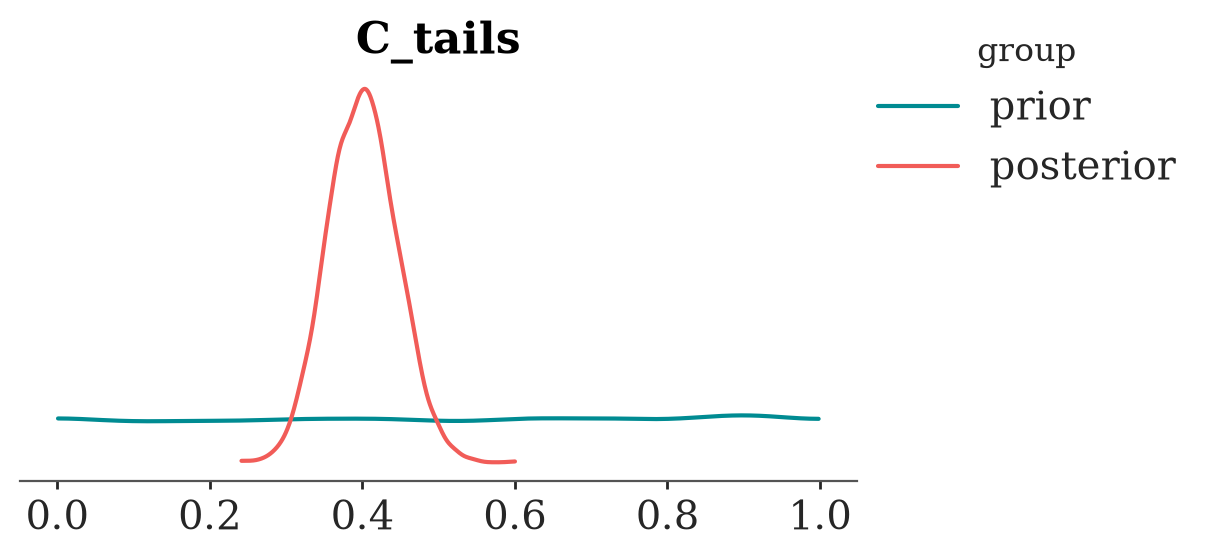

In [7]:
az.plot_prior_posterior(post_samp)

## Final estimate of $C_{\rm{tails}}$

,mean,sd,hdi95_lb,hdi95_ub
C_tails,0.4,0.045,0.31,0.49


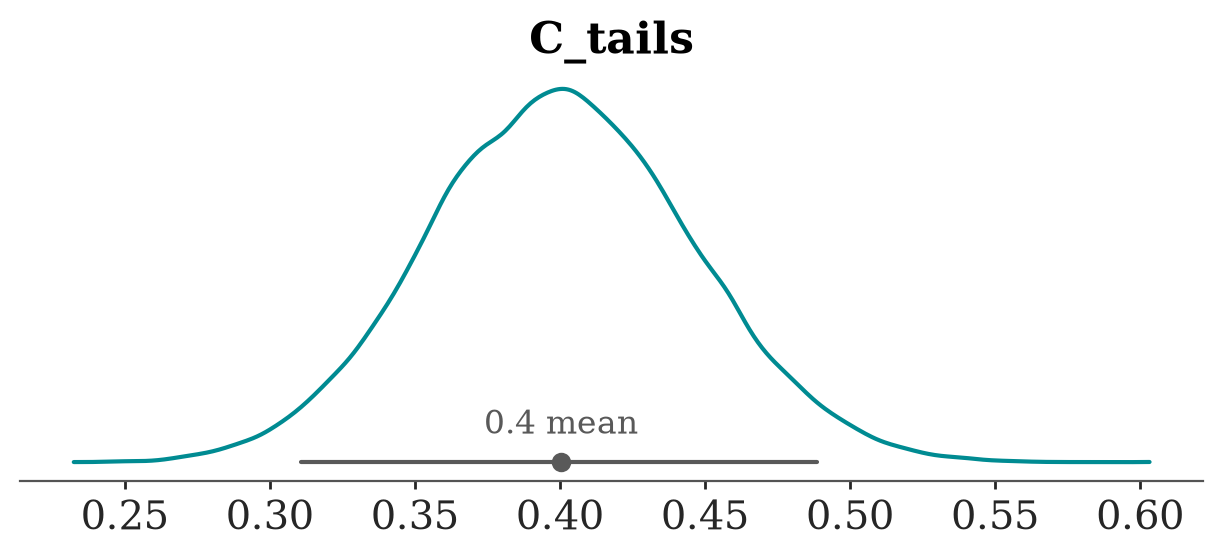

In [8]:
az.plot_dist(post_samp,ci_kind='hdi',ci_prob=0.95)
az.summary(post_samp,kind='stats', ci_kind='hdi', ci_prob=0.95)

So, I can report that with my model, I infer $C_{\rm{tails}}=0.44\pm0.9$ (mean and 95% HDI interval).